# 01.2 Datenexploration – Chicago Wetter 2025

Stündliche Wetterdaten für Chicago aus dem Jahr 2025.  
Quelle: `/data/chicago_weather_2025_hourly.csv` , geladen aus "https://archive-api.open-meteo.com/v1/archive"

**Spalten:**
| Spalte | Beschreibung | Einheit |
|---|---|---|
| `datetime` | Zeitstempel (stündlich) | — |
| `temperature_2m` | Temperatur 2 m über Boden | °C |
| `apparent_temperature` | Gefühlte Temperatur | °C |
| `precipitation` | Niederschlag | mm |
| `snowfall` | Schneefall | cm |
| `wind_speed_10m` | Windgeschwindigkeit 10 m | km/h |
| `cloud_cover` | Bewölkungsgrad | % |
| `weather_code` | WMO-Wettercode | — |
| `weather_description` | Wetterbeschreibung | — |

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 4)

## 1  Daten laden

In [22]:
df = pd.read_csv(
    '../data/chicago_weather_2025_hourly.csv',
    parse_dates=['datetime']
)
df = df.set_index('datetime').sort_index()
print(f'Zeitraum: {df.index.min()}  ->  {df.index.max()}')
print(f'Zeilen: {len(df):,}  |  Spalten: {df.shape[1]}')
df.head()

Zeitraum: 2025-01-01 00:00:00  ->  2025-12-31 23:00:00
Zeilen: 8,760  |  Spalten: 8


,temperature_2m,apparent_temperature,precipitation,snowfall,wind_speed_10m,cloud_cover,weather_code,weather_description
datetime,,,,,,,,
2025-01-01 00:00:00,0.7,-3.6,0.0,0.00,8.6,100,3,Overcast
2025-01-01 01:00:00,0.8,-3.5,0.0,0.00,8.1,100,3,Overcast
2025-01-01 02:00:00,0.6,-3.7,0.0,0.00,8.8,100,3,Overcast
2025-01-01 03:00:00,0.2,-4.8,0.1,0.07,10.7,100,71,Slight snowfall
2025-01-01 04:00:00,-0.2,-5.3,0.0,0.00,10.3,100,3,Overcast


## 2  Grundlegende Übersicht

In [23]:
df.dtypes

temperature_2m          float64
apparent_temperature    float64
precipitation           float64
snowfall                float64
wind_speed_10m          float64
cloud_cover               int64
weather_code              int64
weather_description      object
dtype: object

In [24]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
temperature_2m,8760.0,10.61,11.54,-21.9,2.0,11.0,20.2,35.60
apparent_temperature,8760.0,8.65,14.22,-28.1,-2.2,8.4,20.8,38.90
precipitation,8760.0,0.10,0.51,0.0,0.0,0.0,0.0,10.60
snowfall,8760.0,0.01,0.07,0.0,0.0,0.0,0.0,1.68
wind_speed_10m,8760.0,7.50,3.66,0.1,4.8,7.1,9.8,24.40
cloud_cover,8760.0,57.67,44.10,0.0,3.0,80.0,100.0,100.00
weather_code,8760.0,8.84,19.30,0.0,0.0,3.0,3.0,75.00


## 3  Fehlende Werte

In [25]:
missing = df.isnull().sum()
print('Fehlende Werte pro Spalte:')
print(missing)

expected_hours = pd.date_range('2025-01-01', '2025-12-31 23:00', freq='h')
missing_ts = expected_hours.difference(df.index)
print(f'Erwartete Stunden: {len(expected_hours):,}')
print(f'Fehlende Zeitstempel: {len(missing_ts)}')

Fehlende Werte pro Spalte:
temperature_2m          0
apparent_temperature    0
precipitation           0
snowfall                0
wind_speed_10m          0
cloud_cover             0
weather_code            0
weather_description     0
dtype: int64
Erwartete Stunden: 8,760
Fehlende Zeitstempel: 0


## 4  Temperaturen über das Jahr

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['temperature_2m'], lw=0.6, alpha=0.6, color='steelblue', label='Temperatur (2 m)')
ax.plot(df.index, df['apparent_temperature'], lw=0.6, alpha=0.6, color='coral', label='Gefühlte Temperatur')
daily_mean = df['temperature_2m'].resample('D').mean()
ax.plot(daily_mean.index, daily_mean, lw=1.8, color='navy', label='Tagesmittel (Temp.)')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_title('Temperaturverlauf Chicago 2025 (stündlich)')
ax.set_ylabel('°C')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend()
plt.tight_layout()
plt.show()

## 5  Monatliche Aggregationen

In [ ]:
df['month'] = df.index.month
df['month_name'] = df.index.strftime('%b')

monthly = df.groupby('month').agg(
    temp_mean=('temperature_2m', 'mean'),
    temp_min=('temperature_2m', 'min'),
    temp_max=('temperature_2m', 'max'),
    precip_sum=('precipitation', 'sum'),
    snow_sum=('snowfall', 'sum'),
    wind_mean=('wind_speed_10m', 'mean'),
).round(2)
monthly.index = pd.to_datetime(monthly.index, format='%m').strftime('%b')
monthly

,temp_mean,temp_min,temp_max,precip_sum,snow_sum,wind_mean
month,,,,,,
Jan,-5.39,-21.0,8.4,60.3,9.31,9.21
Feb,-3.24,-21.9,13.2,23.7,11.97,8.43
Mar,6.05,-7.8,24.2,94.1,11.90,8.71
Apr,9.70,-2.3,27.6,64.7,0.21,8.57
May,13.03,5.7,32.2,71.3,0.00,7.04
Jun,22.09,8.4,35.6,124.0,0.00,6.70
Jul,24.57,16.7,35.0,102.5,0.00,5.72
Aug,22.60,13.4,33.8,42.5,0.00,5.82
Sep,19.75,9.9,29.7,38.5,0.00,5.27


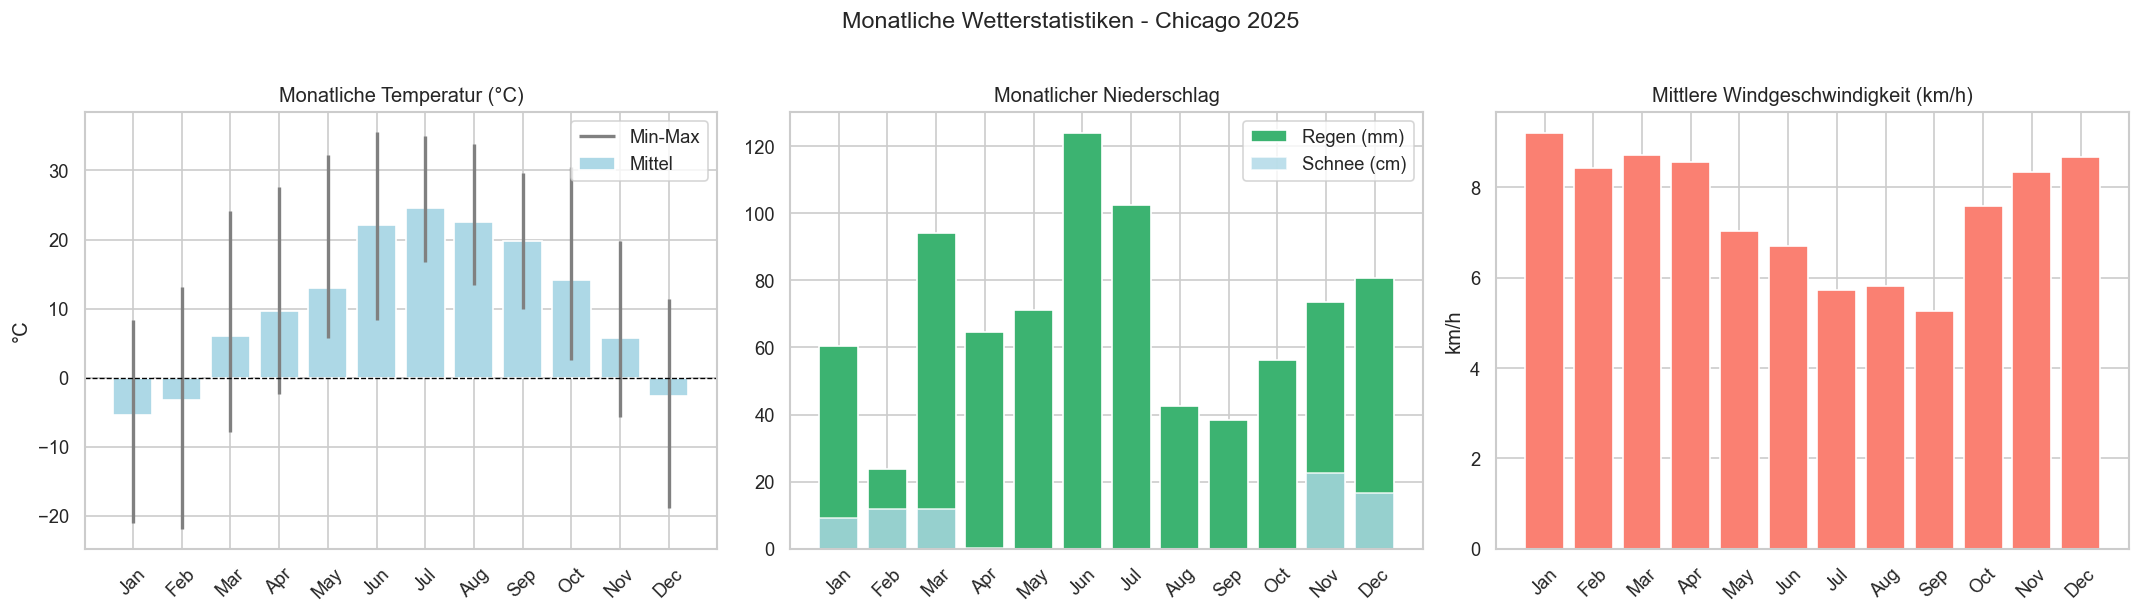

In [ ]:
months = list(monthly.index)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(months, monthly['temp_mean'], color='lightblue', label='Mittel')
axes[0].vlines(months, monthly['temp_min'], monthly['temp_max'], color='gray', lw=2, label='Min-Max')
axes[0].axhline(0, ls='--', color='black', lw=0.8)
axes[0].set_title('Monatliche Temperatur (°C)')
axes[0].set_ylabel('°C')
axes[0].legend()

axes[1].bar(months, monthly['precip_sum'], color='mediumseagreen', label='Regen (mm)')
axes[1].bar(months, monthly['snow_sum'], bottom=0, color='lightblue', alpha=0.8, label='Schnee (cm)')
axes[1].set_title('Monatlicher Niederschlag')
axes[1].legend()

axes[2].bar(months, monthly['wind_mean'], color='salmon')
axes[2].set_title('Mittlere Windgeschwindigkeit (km/h)')
axes[2].set_ylabel('km/h')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Monatliche Wetterstatistiken - Chicago 2025', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6  Jahreszeiten-Analyse

/var/folders/yn/txvzpz5x0bs4ybyt421s_rhc0000gn/T/ipykernel_66103/1704795422.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(season_data, labels=season_order, patch_artist=True,


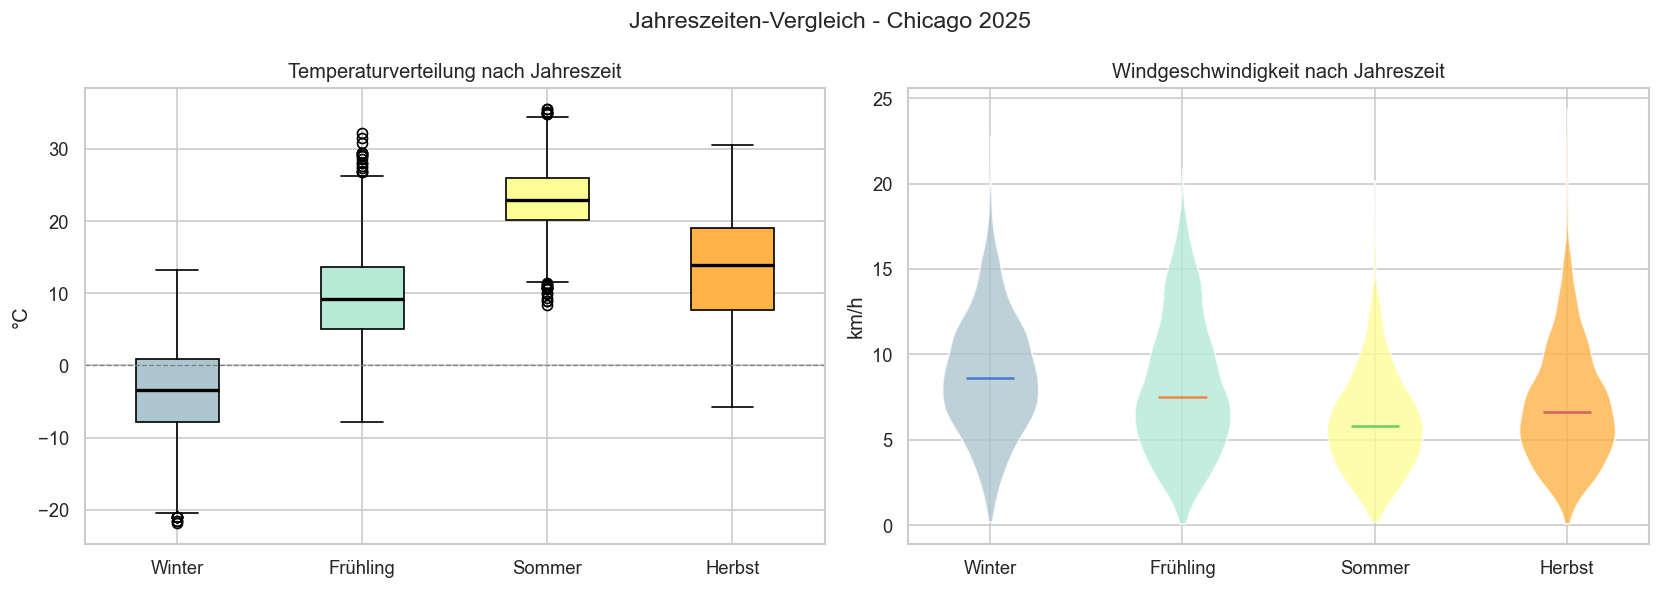

In [ ]:
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Frühling', 4: 'Frühling', 5: 'Frühling',
              6: 'Sommer', 7: 'Sommer', 8: 'Sommer',
              9: 'Herbst', 10: 'Herbst', 11: 'Herbst'}
df['season'] = df['month'].map(season_map)
season_order = ['Winter', 'Frühling', 'Sommer', 'Herbst']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_data = [df.loc[df['season'] == s, 'temperature_2m'].values for s in season_order]
bp = axes[0].boxplot(season_data, labels=season_order, patch_artist=True,
                     medianprops=dict(color='black', lw=2))
colors = ['#aec6cf', '#b5ead7', '#fdfd96', '#ffb347']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].axhline(0, ls='--', color='gray', lw=0.8)
axes[0].set_title('Temperaturverteilung nach Jahreszeit')
axes[0].set_ylabel('°C')

for i, s in enumerate(season_order, 1):
    vals = df.loc[df['season'] == s, 'wind_speed_10m'].values
    parts = axes[1].violinplot(vals, positions=[i], showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(colors[i-1])
        pc.set_alpha(0.8)
axes[1].set_xticks(range(1, 5))
axes[1].set_xticklabels(season_order)
axes[1].set_title('Windgeschwindigkeit nach Jahreszeit')
axes[1].set_ylabel('km/h')

plt.suptitle('Jahreszeiten-Vergleich - Chicago 2025', fontsize=14)
plt.tight_layout()
plt.show()

## 7  Tagesrhythmus (Stundenprofil)

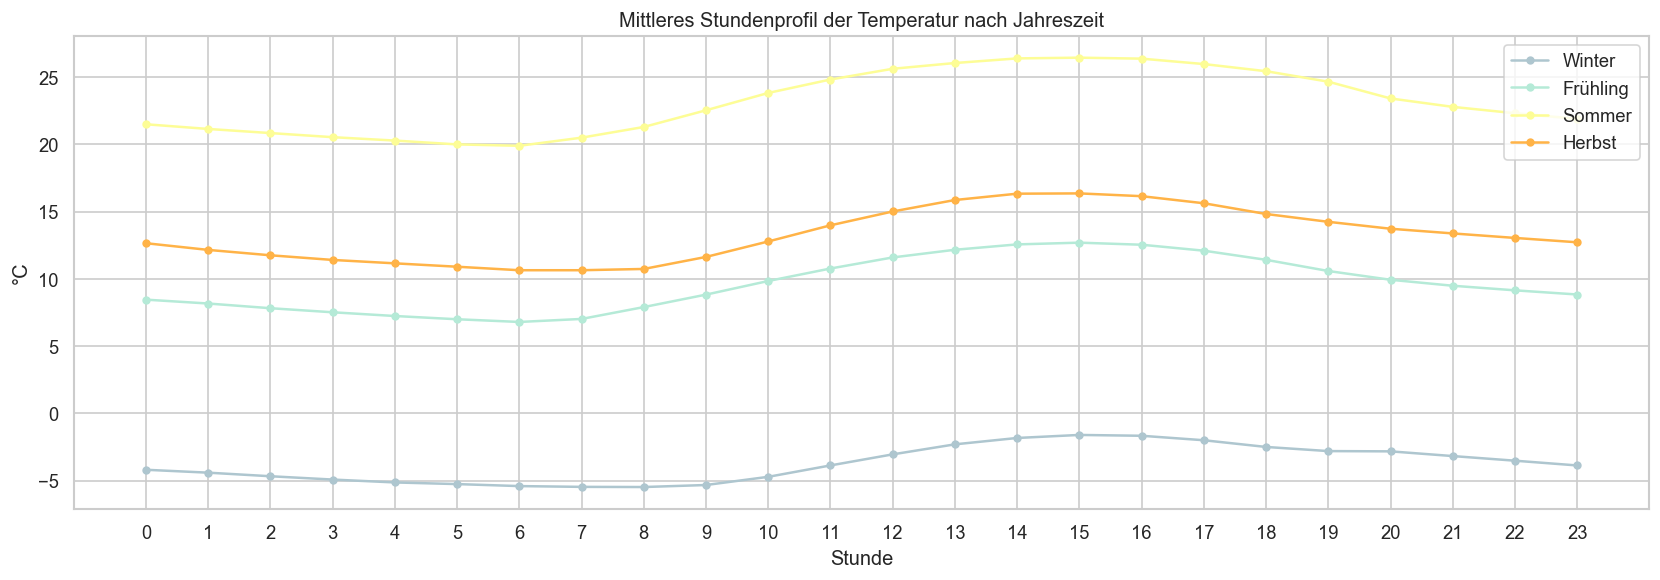

In [ ]:
df['hour'] = df.index.hour
hourly_profile = df.groupby(['season', 'hour'])['temperature_2m'].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 5))
palette = {'Winter': '#aec6cf', 'Frühling': '#b5ead7', 'Sommer': '#fdfd96', 'Herbst': '#ffb347'}
for season in season_order:
    ax.plot(hourly_profile.index, hourly_profile[season], marker='o', ms=4, label=season,
            color=palette[season])
ax.set_title('Mittleres Stundenprofil der Temperatur nach Jahreszeit')
ax.set_xlabel('Stunde')
ax.set_ylabel('°C')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

## 8  Niederschlag & Schnee

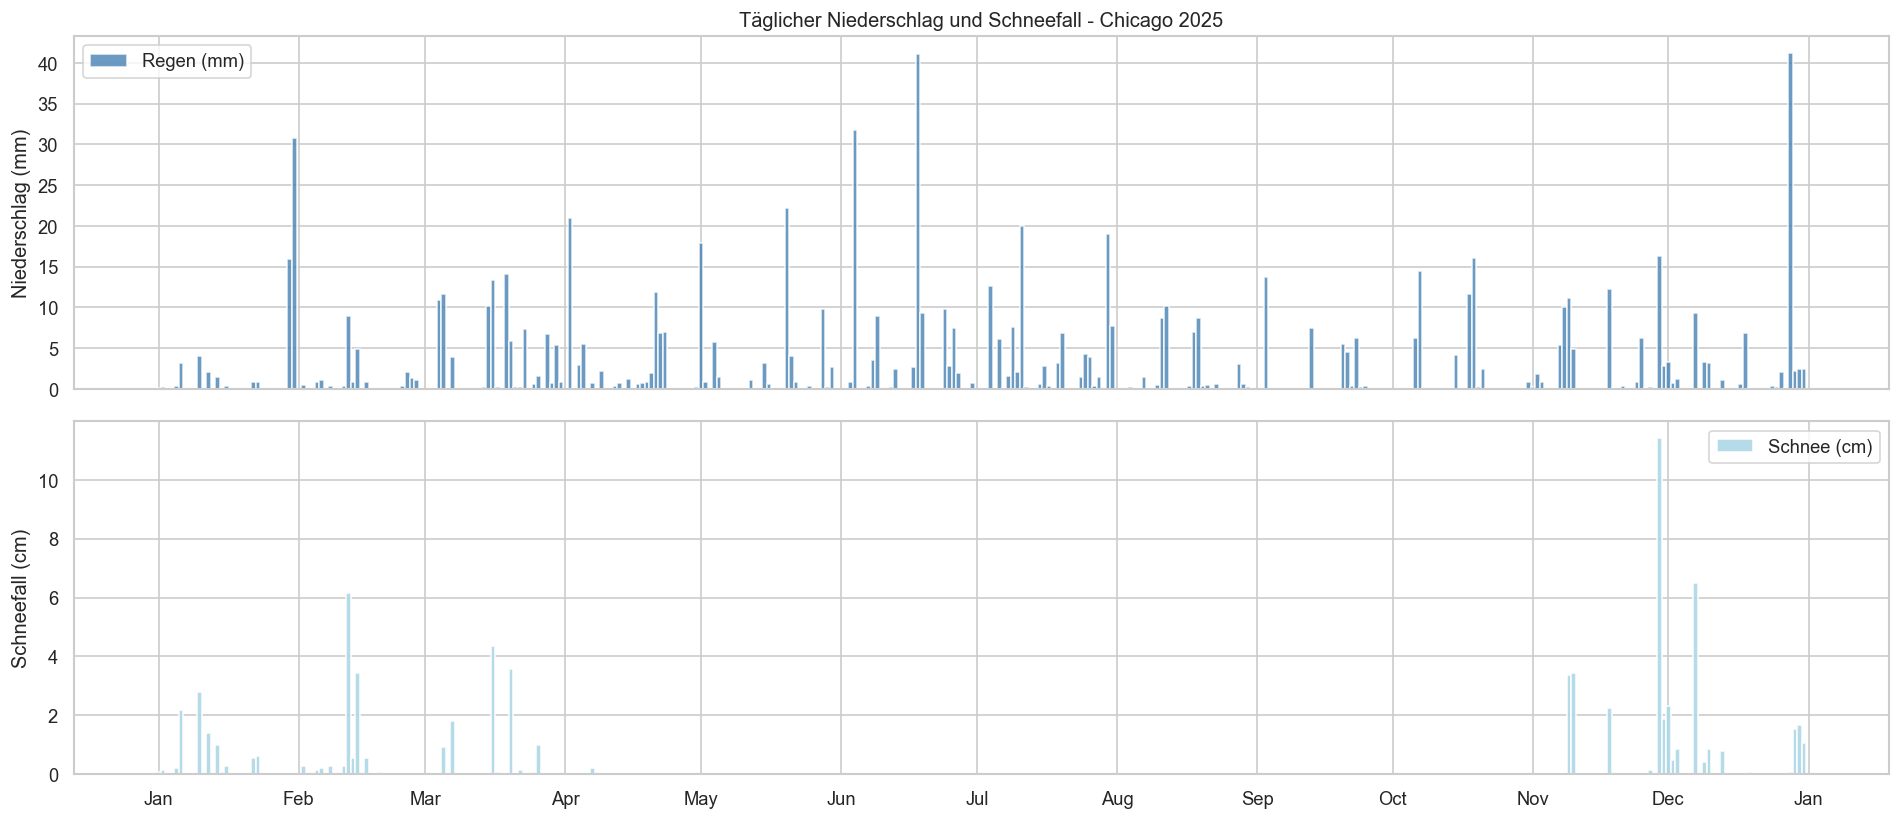

Jahresgesamtniederschlag: 832.3 mm
Jahresgesamtschnee:        72.5 cm
Regentage (>0.1 mm):       166
Schneetage (>0 cm):        48


In [ ]:
daily = df.resample('D').agg(
    precip=('precipitation', 'sum'),
    snow=('snowfall', 'sum'),
    temp=('temperature_2m', 'mean')
)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].bar(daily.index, daily['precip'], width=1, color='steelblue', alpha=0.8, label='Regen (mm)')
axes[0].set_ylabel('Niederschlag (mm)')
axes[0].set_title('Täglicher Niederschlag und Schneefall - Chicago 2025')
axes[0].legend()

axes[1].bar(daily.index, daily['snow'], width=1, color='lightblue', alpha=0.9, label='Schnee (cm)')
axes[1].set_ylabel('Schneefall (cm)')
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Jahresgesamtniederschlag: {daily['precip'].sum():.1f} mm")
print(f"Jahresgesamtschnee:        {daily['snow'].sum():.1f} cm")
print(f"Regentage (>0.1 mm):       {(daily['precip'] > 0.1).sum()}")
print(f"Schneetage (>0 cm):        {(daily['snow'] > 0).sum()}")

## 9  Wettercode-Verteilung

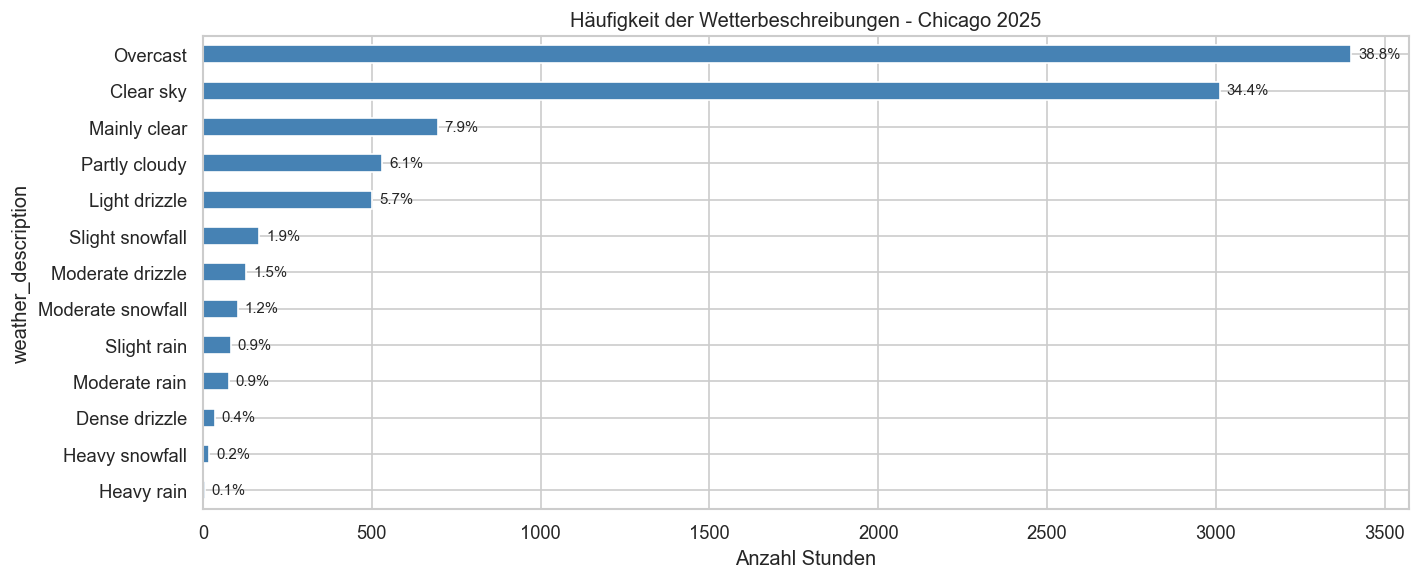

In [ ]:
desc_counts = df['weather_description'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
desc_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Häufigkeit der Wetterbeschreibungen - Chicago 2025')
ax.set_xlabel('Anzahl Stunden')
ax.invert_yaxis()
for i, v in enumerate(desc_counts):
    pct = v / len(df) * 100
    ax.text(v + 20, i, f'{pct:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 10  Korrelationsmatrix

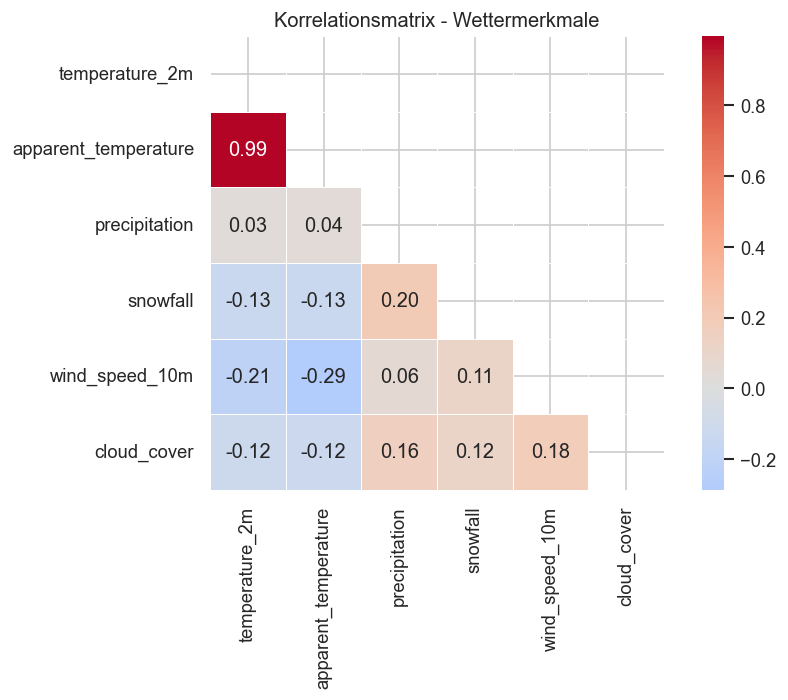

In [ ]:
numeric_cols = ['temperature_2m', 'apparent_temperature', 'precipitation',
                'snowfall', 'wind_speed_10m', 'cloud_cover']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Korrelationsmatrix - Wettermerkmale')
plt.tight_layout()
plt.show()

## 11  Extremwerte & Kennzahlen

In [ ]:
print('=== Temperatur-Extremwerte ===')
print(f"Höchste Temperatur:  {df['temperature_2m'].max():.1f} °C  am {df['temperature_2m'].idxmax()}")
print(f"Niedrigste Temperatur: {df['temperature_2m'].min():.1f} °C  am {df['temperature_2m'].idxmin()}")
print(f"Jahresschnitt:         {df['temperature_2m'].mean():.1f} °C")

print('=== Gefühlte Temperatur-Extreme ===')
print(f"Kälteste gefühlte Temp.: {df['apparent_temperature'].min():.1f} °C  am {df['apparent_temperature'].idxmin()}")

print('=== Stärkstes Niederschlagsereignis ===')
print(f"Max. stündlicher Regen:  {df['precipitation'].max():.1f} mm  am {df['precipitation'].idxmax()}")

print('=== Wind ===')
print(f"Höchste Windgeschwindigkeit: {df['wind_speed_10m'].max():.1f} km/h  am {df['wind_speed_10m'].idxmax()}")
print(f"Mittlere Windgeschwindigkeit: {df['wind_speed_10m'].mean():.1f} km/h")

print('=== Bewölkung ===')
print(f"Anteil vollständig bedeckter Himmel (100%): {(df['cloud_cover']==100).mean()*100:.1f}%")
print(f"Anteil klarer Himmel (<=10%):                {(df['cloud_cover']<=10).mean()*100:.1f}%")

=== Temperatur-Extremwerte ===
Höchste Temperatur:  35.6 °C  am 2025-06-23 15:00:00
Niedrigste Temperatur: -21.9 °C  am 2025-02-18 07:00:00
Jahresschnitt:         10.6 °C
=== Gefühlte Temperatur-Extreme ===
Kälteste gefühlte Temp.: -28.1 °C  am 2025-02-18 07:00:00
=== Stärkstes Niederschlagsereignis ===
Max. stündlicher Regen:  10.6 mm  am 2025-06-18 08:00:00
=== Wind ===
Höchste Windgeschwindigkeit: 24.4 km/h  am 2025-11-26 13:00:00
Mittlere Windgeschwindigkeit: 7.5 km/h
=== Bewölkung ===
Anteil vollständig bedeckter Himmel (100%): 37.8%
Anteil klarer Himmel (<=10%):                30.2%


## 12  Heatmap: Temperatur nach Monat und Stunde

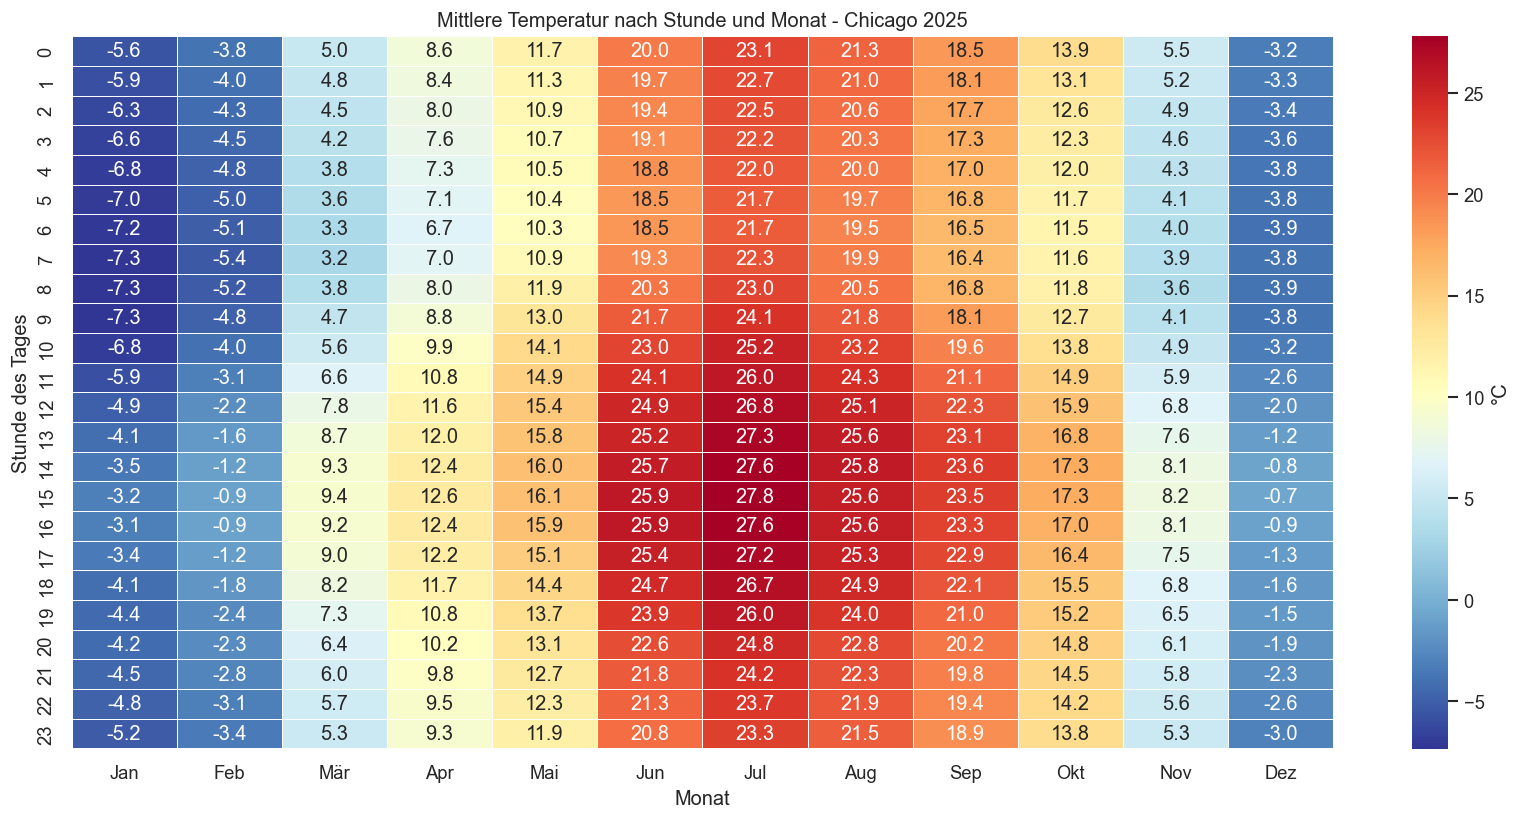

In [ ]:
pivot = df.pivot_table(values='temperature_2m', index='hour', columns='month', aggfunc='mean')
pivot.columns = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, cmap='RdYlBu_r', annot=True, fmt='.1f', linewidths=0.3,
            cbar_kws={'label': '°C'}, ax=ax)
ax.set_title('Mittlere Temperatur nach Stunde und Monat - Chicago 2025')
ax.set_xlabel('Monat')
ax.set_ylabel('Stunde des Tages')
plt.tight_layout()
plt.show()

## 13  Zusammenfassung

| Kennzahl | Wert |
|---|---|
| Datenpunkte | 8 760 (stündlich, vollständig) |
| Jahrestemperatur Ø | ~11 °C |
| Wärmster Monat | Juli / August |
| Kältester Monat | Januar / Februar |
| Schnee vorhanden | Jan, Feb, Nov, Dez |
| Dominantes Wetter | Overcast / Clear sky |

**Kernbeobachtungen:**
- Starker saisonaler Temperaturunterschied (~-15 °C im Winter bis ~35 °C im Sommer)
- Gefühlte Temperatur weicht durch Wind im Winter stark nach unten ab
- Niederschlag relativ gleichmäßig über das Jahr verteilt, Schnee auf Wintermonate beschränkt
- Starke positive Korrelation zwischen Temperatur und gefühlter Temperatur (erwartungsgemäß)
- Bewölkung zeigt negative Korrelation mit Temperatur